# CE49X: Introduction to Computational Thinking and Data Science for Civil Engineers
## Week 8: Support Vector Machines

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

Based on *Python Data Science Handbook* by Jake VanderPlas  
Chapter 5: Machine Learning (Section 5.07 - Support Vector Machines)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
%matplotlib inline

## Quick Recap: Where Are We?

In the last two weeks, we learned about **Naive Bayes** — our first machine learning classifier. Naive Bayes is a *generative* model: it learns what each class "looks like" by estimating probability distributions, then uses Bayes' theorem to classify new data.

Today we learn a fundamentally different approach: **Support Vector Machines (SVMs)**. Instead of modeling what each class looks like, SVMs focus entirely on finding the **best boundary** between classes. This makes them *discriminative* classifiers.

**Why should you care about SVMs?**
- They are one of the most powerful "classical" ML algorithms (before deep learning took over)
- They work surprisingly well on small-to-medium datasets — common in civil engineering
- They introduce key ML concepts: **margins**, **kernels**, and **regularization**
- Real applications: structural health monitoring, crack detection, material classification

## Table of Contents

1. [Introduction to Support Vector Machines](#1.-Introduction-to-Support-Vector-Machines)
2. [Maximum Margin Classification](#2.-Maximum-Margin-Classification)
3. [Beyond Linear Boundaries: Kernel SVM](#3.-Beyond-Linear-Boundaries:-Kernel-SVM)
4. [Tuning the SVM: Softening Margins](#4.-Tuning-the-SVM:-Softening-Margins)
5. [Example: Face Recognition](#5.-Example:-Face-Recognition)
6. [Support Vector Machine Summary](#6.-Support-Vector-Machine-Summary)

---
## 1. Introduction to Support Vector Machines

### What are Support Vector Machines?

**The Big Idea (in plain English):**

Imagine you have a table with red marbles on one side and blue marbles on the other. You want to place a ruler on the table so that all red marbles are on one side and all blue marbles are on the other. That ruler is your **decision boundary**.

Now, you don't just want *any* ruler placement — you want the one that leaves the **most space** between the ruler and the nearest marbles on each side. That way, if someone bumps the table slightly, the marbles still stay on their correct sides.

**That's exactly what an SVM does.** It finds the decision boundary that maximizes the "gap" (called the **margin**) between the two classes.

**More formally:**
- SVMs are a **discriminative classifier** — they directly find decision boundaries
- This is different from Naive Bayes (a generative model that models each class separately)
- SVMs can handle both **classification** (today's focus) and **regression** tasks
- They are one of the most effective ML algorithms for medium-sized datasets

> **Key Idea**  
> Find the decision boundary that maximizes the margin between classes

### Motivating Example: The Ambiguity Problem

**The Setup:**

Consider two groups of points that are clearly separated in 2D space. We want to draw a line to separate them.

**The Problem:**
- There are **infinitely many lines** that perfectly separate the two groups
- Each line would classify new (unseen) points differently
- So which line should we pick?

Think of it this way: if you're building a fence between two properties, you want the fence to be as far from both houses as possible — not hugging one house while leaving a huge gap on the other side.

> **Key Insight: The SVM Solution**  
> Among all possible separating lines, choose the one that maximizes the distance to the nearest data points from each class

### [LIVE] Visualizing Multiple Decision Boundaries

Let's generate two well-separated classes and draw several lines that all perfectly separate them. This illustrates the ambiguity that SVM resolves.

/var/folders/ls/c59j42ld0z17bbbp9vkns59w0000gn/T/ipykernel_74718/3559282497.py:14: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-k" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(xfit, 0.5 * xfit + 1.6, '-k', linewidth=1, linestyle='--', label='Line 2')
/var/folders/ls/c59j42ld0z17bbbp9vkns59w0000gn/T/ipykernel_74718/3559282497.py:15: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-k" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(xfit, -0.2 * xfit + 2.9, '-k', linewidth=1, linestyle='-.', label='Line 3')


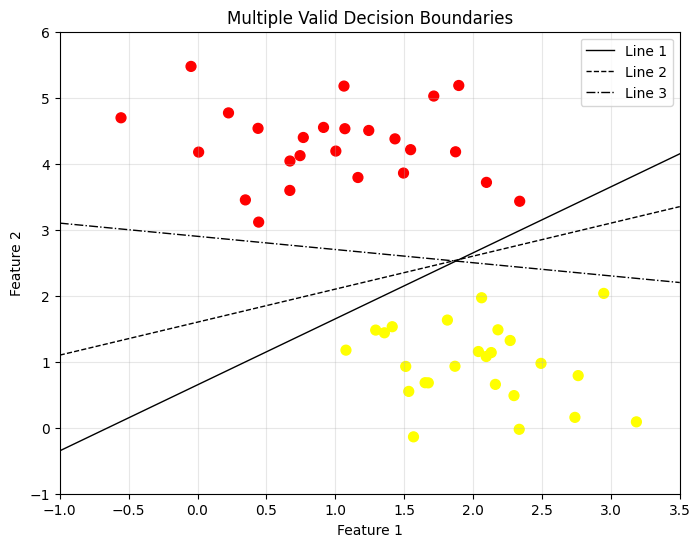

All three lines perfectly separate the training data.
But they would classify new points differently!
Which line should we trust?


In [2]:
from sklearn.datasets import make_blobs

# Generate sample data with two well-separated clusters
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

# Plot data with three arbitrary separating lines
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

# Draw three plausible separating lines
xfit = np.linspace(-1, 3.5)
ax.plot(xfit, 1 * xfit + 0.65, '-k', linewidth=1, label='Line 1')
ax.plot(xfit, 0.5 * xfit + 1.6, '-k', linewidth=1, linestyle='--', label='Line 2')
ax.plot(xfit, -0.2 * xfit + 2.9, '-k', linewidth=1, linestyle='-.', label='Line 3')

ax.set_xlim(-1, 3.5)
ax.set_ylim(-1, 6)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Multiple Valid Decision Boundaries')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("All three lines perfectly separate the training data.")
print("But they would classify new points differently!")
print("Which line should we trust?")

---
## 2. Maximum Margin Classification

### The Margin Concept

**SVM's Answer: Pick the Line with the Widest "Buffer Zone"**

Instead of just drawing a thin line, imagine widening it into a **band** (like a road instead of a path). Widen it as much as possible until it touches the nearest data points on each side.

**Key Definitions:**
- **Decision boundary:** The line (or plane) that separates the two classes
- **Margin:** The perpendicular distance from the decision boundary to the nearest data point on each side — think of it as the width of the "no-man's land" between classes
- **Support vectors:** The data points that sit right on the edge of the margin (we'll explain these in detail shortly)

**Why maximize the margin?**
- A wider margin means the classifier is more **confident** about its predictions
- Small perturbations in the data won't change the classification
- It leads to better **generalization** — meaning it works better on new, unseen data

> **Key Insight**  
> The line that maximizes the margin is the one we choose as the optimal model

### [TOGETHER] Visualizing Margins

The following visualization shows the optimal decision boundary (solid line), the margin boundaries (dashed lines), and the support vectors (circled points).

In [3]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC."""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X_grid = np.meshgrid(y, x)
    xy = np.vstack([X_grid.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X_grid.shape)

    # Plot decision boundary and margins
    ax.contour(X_grid, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # Plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none',
                   edgecolors='black')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

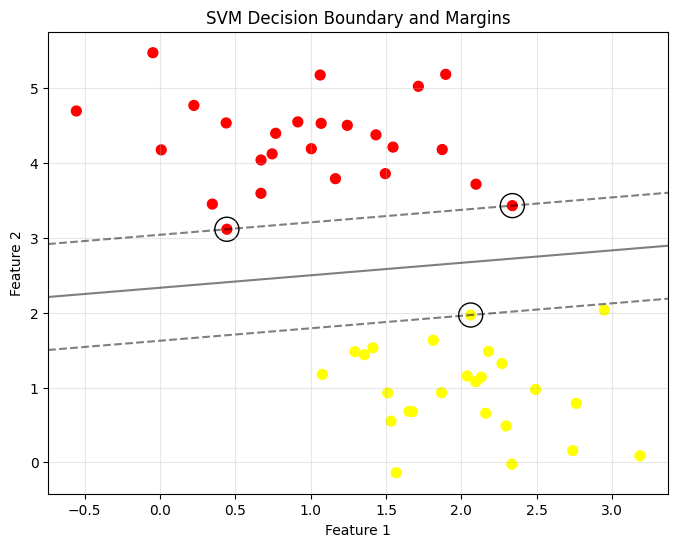

Solid line: optimal decision boundary
Dashed lines: margin boundaries
Circled points: support vectors (the points that define the boundary)


In [4]:
# Generate sample data
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

# Create and fit the SVM model with a hard margin
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

# Plot decision boundary with margins
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model, ax)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('SVM Decision Boundary and Margins')
ax.grid(True, alpha=0.3)
plt.show()

print("Solid line: optimal decision boundary")
print("Dashed lines: margin boundaries")
print("Circled points: support vectors (the points that define the boundary)")

### Support Vectors: The Key Players

**What are support vectors?**

Support vectors are the training points that sit exactly on the margin boundary. They are the "closest" points to the decision boundary from each class.

**Why are they special?**
- They are the **only** points that determine where the decision boundary goes
- Every other point in the dataset could be moved, added, or removed and the boundary would stay the same
- This is why the algorithm is called **Support Vector** Machine — these vectors literally "support" (hold up) the decision boundary

**An analogy:** Imagine two opposing walls held apart by a few pillars. The pillars are the support vectors. You can add or remove bricks from the walls (non-support-vector points) and the gap between the walls stays the same. But if you move a pillar, the whole structure changes.

> **Example: Efficiency**  
> Even with thousands of training points, often only a handful are support vectors. This makes SVM memory-efficient.

In [5]:
# Display the support vectors
print("Support Vectors:")
print(model.support_vectors_)
print(f"\nNumber of support vectors: {len(model.support_vectors_)}")
print(f"Total training points: {len(X)}")
print(f"\nOnly {len(model.support_vectors_)} out of {len(X)} points define the boundary!")
print("The other", len(X) - len(model.support_vectors_), "points don't affect the model at all.")

Support Vectors:
[[0.44359863 3.11530945]
 [2.33812285 3.43116792]
 [2.06156753 1.96918596]]

Number of support vectors: 3
Total training points: 50

Only 3 out of 50 points define the boundary!
The other 47 points don't affect the model at all.


### Fitting an SVM in Scikit-Learn

Let's see how simple it is to use SVM in code. The API is the same `fit` / `predict` pattern you learned with Naive Bayes.

In [6]:
from sklearn.svm import SVC  # "Support Vector Classifier"
from sklearn.datasets import make_blobs

# Step 1: Generate sample data
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

# Step 2: Create and fit the SVM model
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

# Step 3: The support vectors are stored in the model
print("Support vector coordinates:")
print(model.support_vectors_)

# Step 4: Make predictions
predictions = model.predict(X)
print(f"\nTraining accuracy: {accuracy_score(y, predictions):.2%}")

Support vector coordinates:
[[0.44359863 3.11530945]
 [2.33812285 3.43116792]
 [2.06156753 1.96918596]]

Training accuracy: 100.00%


**Key Parameters Explained:**
- `kernel='linear'`: Use a straight line (or flat plane) as the decision boundary. We'll explore other kernels soon.
- `C=1E10`: A very large C value means "hard margin" — don't allow *any* misclassifications. We'll discuss what C really means in Section 4.

### SVM Model Stability

**A Key Strength: Insensitivity to Distant Points**

Because only support vectors matter, adding more data points far from the boundary doesn't change the model at all. Let's demonstrate this:

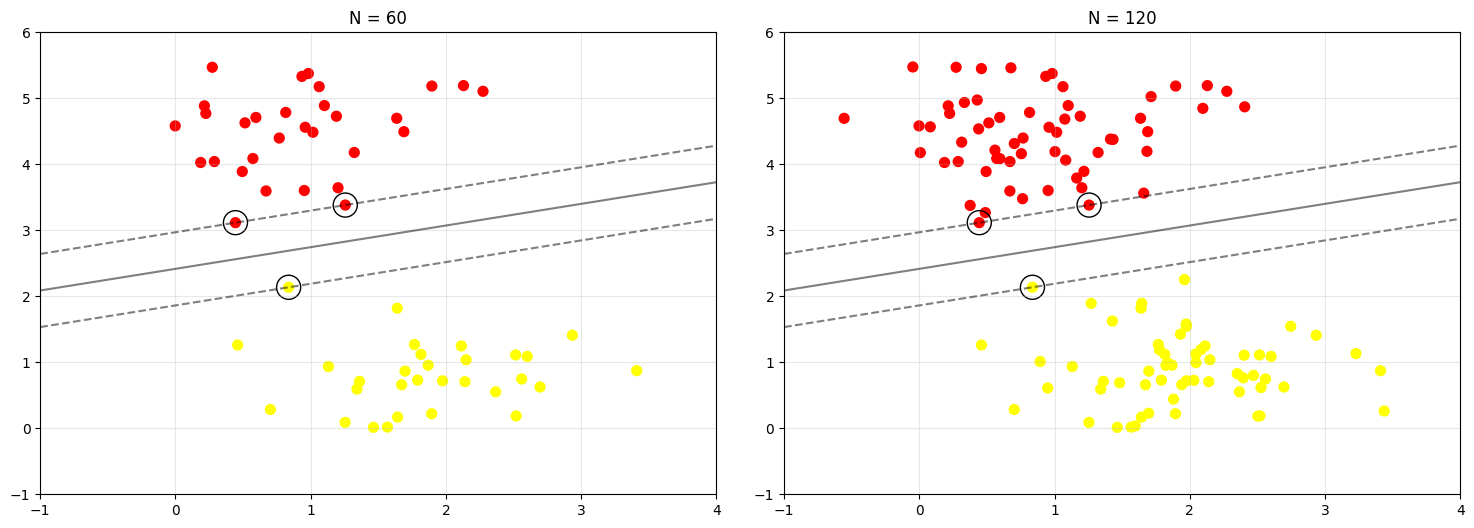

Notice: The decision boundary is IDENTICAL in both plots!
Doubling the training data didn't change the model at all,
because the support vectors remained the same.


In [7]:
def plot_svm(N=10, ax=None):
    """Plot SVM with N training points."""
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

# Compare models with different numbers of points
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title(f'N = {N}')
    axi.grid(True, alpha=0.3)

plt.show()

print("Notice: The decision boundary is IDENTICAL in both plots!")
print("Doubling the training data didn't change the model at all,")
print("because the support vectors remained the same.")

---
## 3. Beyond Linear Boundaries: Kernel SVM

### When Straight Lines Aren't Enough

**The Problem:**

So far, our SVM draws straight lines (or flat planes). But what if the data looks like this?

- Imagine a bullseye target: inner ring = Class A, outer ring = Class B
- No straight line can separate these two classes
- A linear SVM will fail here

**This happens a lot in the real world:**
- Crack vs. no-crack in concrete images — the boundary isn't a straight line
- Healthy vs. damaged structural responses — non-linear sensor patterns
- Any dataset where the classes are interleaved or wrapped around each other

> **Key Insight: Solution — Kernel Methods**  
> Project the data into a higher-dimensional space where it *becomes* linearly separable, then apply linear SVM in that new space

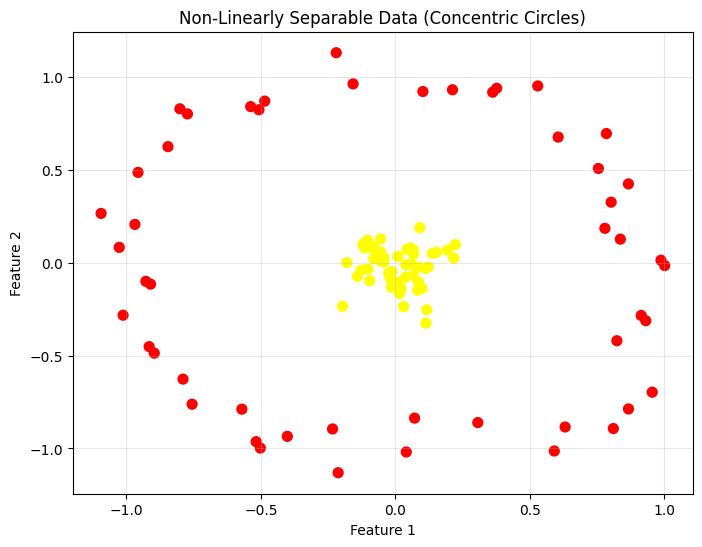

Try drawing a straight line to separate red from yellow... impossible!


In [8]:
from sklearn.datasets import make_circles

# Generate concentric circles — a classic non-linearly separable dataset
X, y = make_circles(100, factor=.1, noise=.1)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Non-Linearly Separable Data (Concentric Circles)')
plt.grid(True, alpha=0.3)
plt.show()

print("Try drawing a straight line to separate red from yellow... impossible!")

### The Kernel Trick: Intuition

**The brilliant idea behind kernel SVM:**

If you can't separate the data in its current space, **add a new dimension** that makes separation possible.

**Step-by-step example with our concentric circles:**

1. Our data lives in 2D: each point has coordinates $(x, y)$
2. We compute a new feature: $r = e^{-(x^2 + y^2)}$ — this is the "radial distance" from the center
3. Now each point has coordinates $(x, y, r)$ — we're in 3D!
4. In 3D, the inner circle points have high $r$ values and the outer circle has low $r$ values
5. A **flat plane** in 3D can now separate them perfectly!

The SVM then finds this separating plane in 3D, and when we project it back to 2D, it appears as a **curved boundary**.

> **Example: Kernel Functions**  
> A kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ computes this transformation *implicitly* — it gets the same result without actually constructing the high-dimensional space. This is computationally much cheaper.

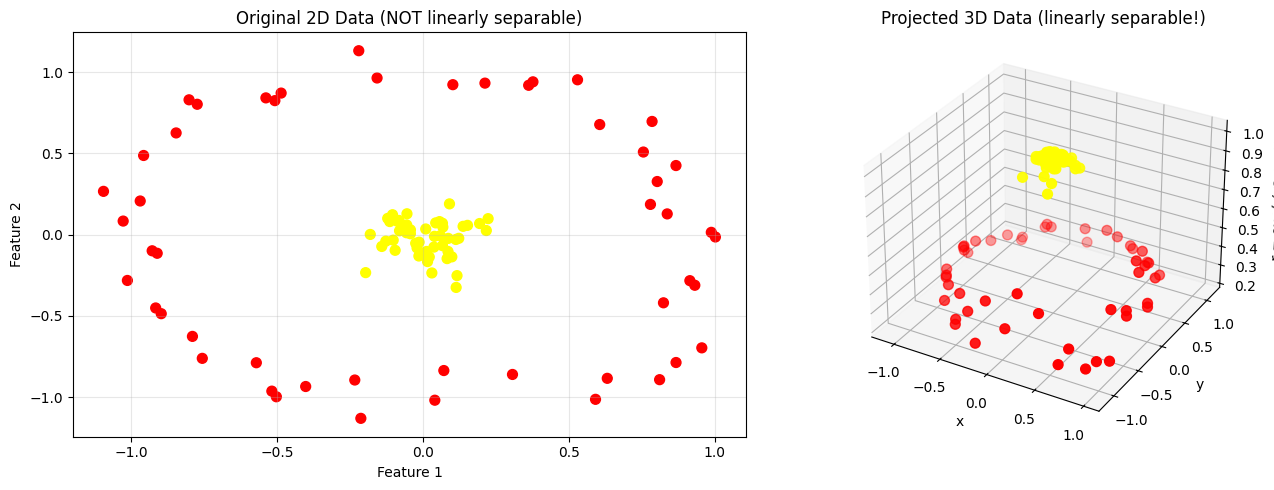

Left: In 2D, the classes are hopelessly intertwined.
Right: In 3D (after adding the radial feature), a flat plane can separate them!


In [9]:
# Visualize the kernel transformation: 2D -> 3D
# Compute radial basis function for visualization
r = np.exp(-(X ** 2).sum(1))

from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(14, 5))

# Original 2D data
ax1 = fig.add_subplot(121)
ax1.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Original 2D Data (NOT linearly separable)')
ax1.grid(True, alpha=0.3)

# Projected 3D data
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('r = exp(-(x² + y²))')
ax2.set_title('Projected 3D Data (linearly separable!)')

plt.tight_layout()
plt.show()

print("Left: In 2D, the classes are hopelessly intertwined.")
print("Right: In 3D (after adding the radial feature), a flat plane can separate them!")

### Radial Basis Function (RBF) Kernel

**The Most Popular Kernel: RBF (also called the Gaussian Kernel)**

The RBF kernel generalizes the idea we just saw. Instead of manually engineering a transformation, it:

1. Places a Gaussian (bell curve) centered at **every** training point
2. Measures how "similar" any new point is to each training point
3. Effectively projects the data into a very high-dimensional space

**The RBF Kernel Formula:**

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

**What does this mean in plain English?**
- If two points $\mathbf{x}_i$ and $\mathbf{x}_j$ are close together, $K$ is close to 1 (very similar)
- If they are far apart, $K$ is close to 0 (very different)
- The parameter $\gamma$ controls how quickly similarity drops off with distance

**The Kernel Trick:**
- Technically, the RBF kernel projects $N$ points into an $N$-dimensional space
- But the kernel trick lets us compute the result **without** actually building that huge space
- This makes it computationally feasible even for large datasets

### [LIVE] Kernel SVM Visualization: Linear vs. RBF

Let's compare a linear kernel (which fails on concentric circles) with the RBF kernel (which succeeds).

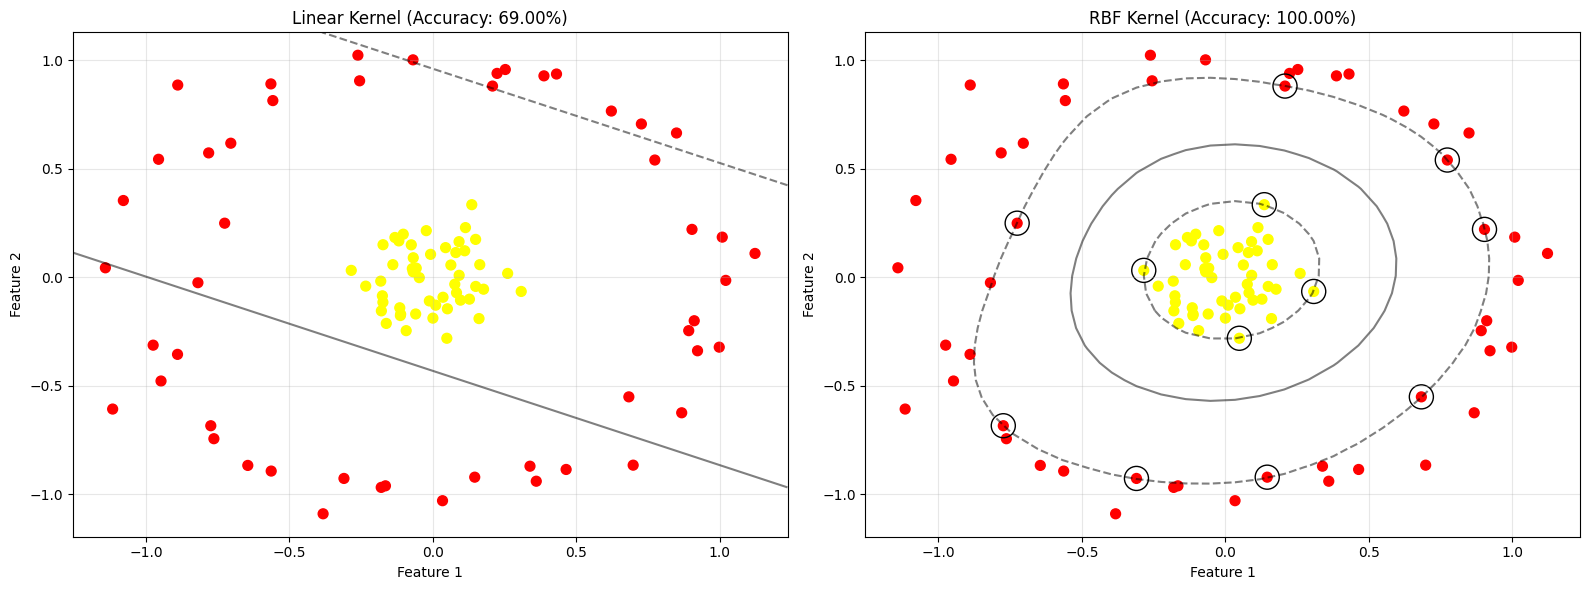

Left: Linear kernel CANNOT separate concentric circles — it draws a straight line through them.
Right: RBF kernel creates a curved decision boundary and separates them perfectly!


In [10]:
# Generate concentric circles
X, y = make_circles(100, factor=.1, noise=.1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Linear kernel (fails)
clf_linear = SVC(kernel='linear').fit(X, y)
axes[0].scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf_linear, axes[0], plot_support=False)
axes[0].set_title(f'Linear Kernel (Accuracy: {clf_linear.score(X, y):.2%})')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# Right: RBF kernel (succeeds)
clf_rbf = SVC(kernel='rbf', C=1E6).fit(X, y)
axes[1].scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf_rbf, axes[1])
axes[1].set_title(f'RBF Kernel (Accuracy: {clf_rbf.score(X, y):.2%})')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: Linear kernel CANNOT separate concentric circles — it draws a straight line through them.")
print("Right: RBF kernel creates a curved decision boundary and separates them perfectly!")

### Common Kernel Functions

Scikit-Learn provides several kernels:

| Kernel | Formula | When to Use |
|--------|---------|-------------|
| Linear | $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$ | Data is linearly separable, or you have very many features |
| Polynomial | $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\, \mathbf{x}_i \cdot \mathbf{x}_j + r)^d$ | You suspect polynomial relationships in your data |
| RBF (Gaussian) | $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$ | **Default choice** — works well for most non-linear problems |
| Sigmoid | $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma\, \mathbf{x}_i \cdot \mathbf{x}_j + r)$ | Rarely used; similar to neural networks |

**Practical Advice:**
- **Start with linear** — it's fast and interpretable. If it works well enough, stop there.
- **Try RBF next** — it's the most versatile and works on most non-linear problems.
- **Polynomial** can be slow and is only worth trying if you have domain knowledge suggesting polynomial relationships.

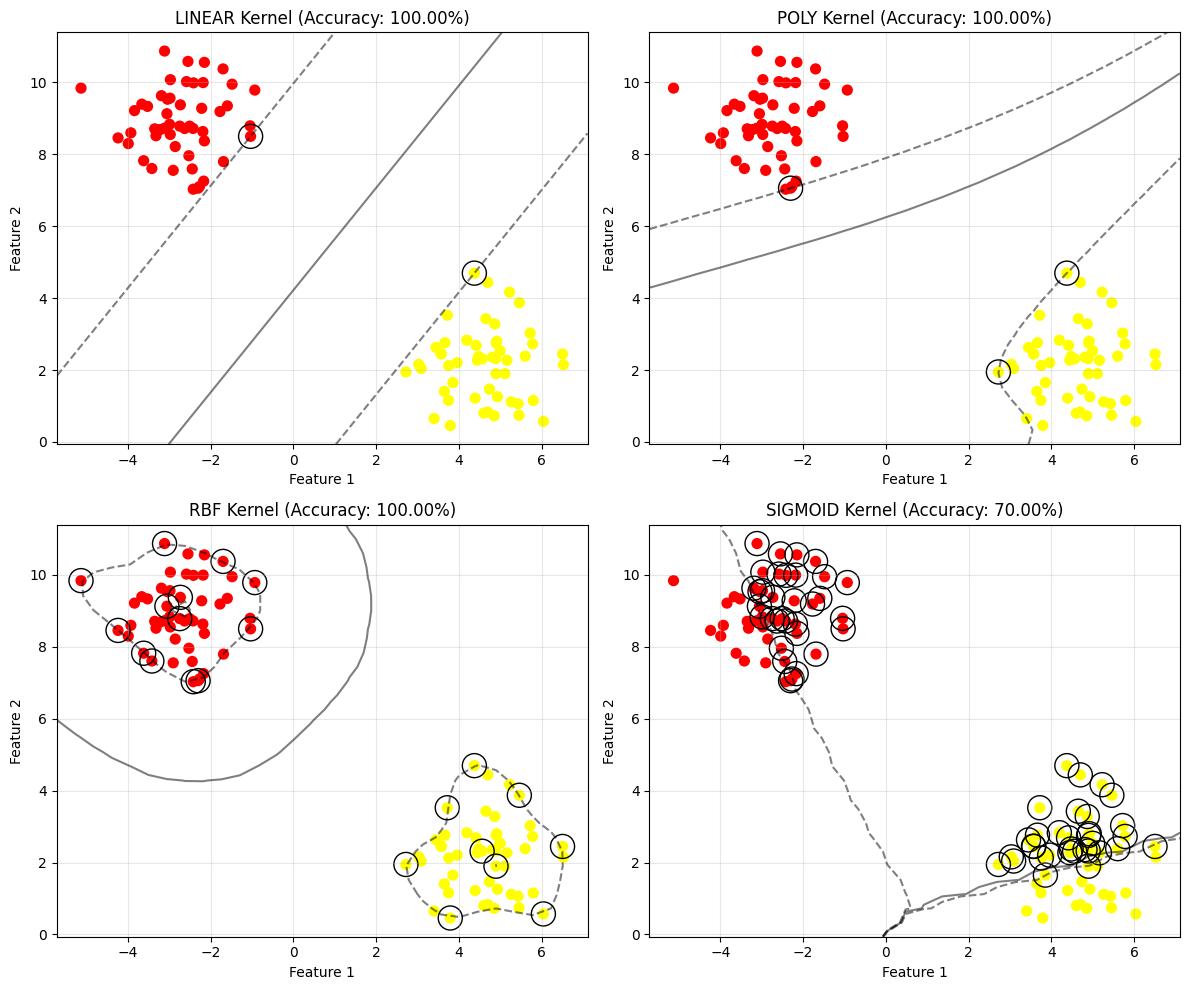

On linearly separable data, all kernels perform similarly.
The differences become apparent on non-linear data (like our circles).


In [11]:
# Compare all kernel types on linearly separable data
X_blobs, y_blobs = make_blobs(n_samples=100, centers=2,
                              random_state=42, cluster_std=1.0)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, kernel in enumerate(kernels):
    model = SVC(kernel=kernel, C=1.0, gamma='auto')
    model.fit(X_blobs, y_blobs)

    axes[idx].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, s=50, cmap='autumn')
    plot_svc_decision_function(model, axes[idx])
    axes[idx].set_title(f'{kernel.upper()} Kernel (Accuracy: {model.score(X_blobs, y_blobs):.2%})')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("On linearly separable data, all kernels perform similarly.")
print("The differences become apparent on non-linear data (like our circles).")

---
## 4. Tuning the SVM: Softening Margins

### The Problem with Hard Margins

**Real data is messy!**

Everything we've seen so far assumed the data is perfectly separable. But in real engineering problems:
- Classes often **overlap** — a concrete sample might show properties of both "healthy" and "damaged"
- There may be **outliers** — a mislabeled data point or a measurement error
- **Perfect separation may not exist** in the original feature space

**What happens if we insist on a hard margin?**
- The model might find no valid boundary at all (and crash)
- Or it might create an extremely narrow, complex boundary that overfits the noise
- One outlier can completely change the decision boundary

**The Solution: Allow some mistakes!**
- Let some points fall **within** or even on the **wrong side** of the margin
- Trade off between a wide margin (more robust) and fewer misclassifications (more accurate on training data)
- This trade-off is controlled by a single parameter: **C**

### The C Parameter: Controlling the Trade-off

The $C$ parameter is the most important hyperparameter in SVM. Think of it as a "strictness" dial:

**Large C (e.g., $C = 1000$) — "Be strict!"**
- Penalizes misclassifications heavily
- Creates a **narrow** margin
- Tries to classify all training points correctly
- Risk: **overfitting** (memorizes noise in the data)

**Small C (e.g., $C = 0.1$) — "Be flexible!"**
- Tolerates some misclassifications
- Creates a **wide** margin
- Better generalization to new data
- Risk: **underfitting** (too simple, misses real patterns)

> **Key Insight: Civil Engineering Analogy**  
> Think of C as a safety factor. A very high safety factor (large C) makes the structure handle every extreme case, but it's expensive and may be over-designed. A moderate safety factor (small C) is more practical and handles most cases well.

### [LIVE] Soft Margin Visualization

Let's compare a large C (hard margin, narrow boundary) with a small C (soft margin, wide boundary).

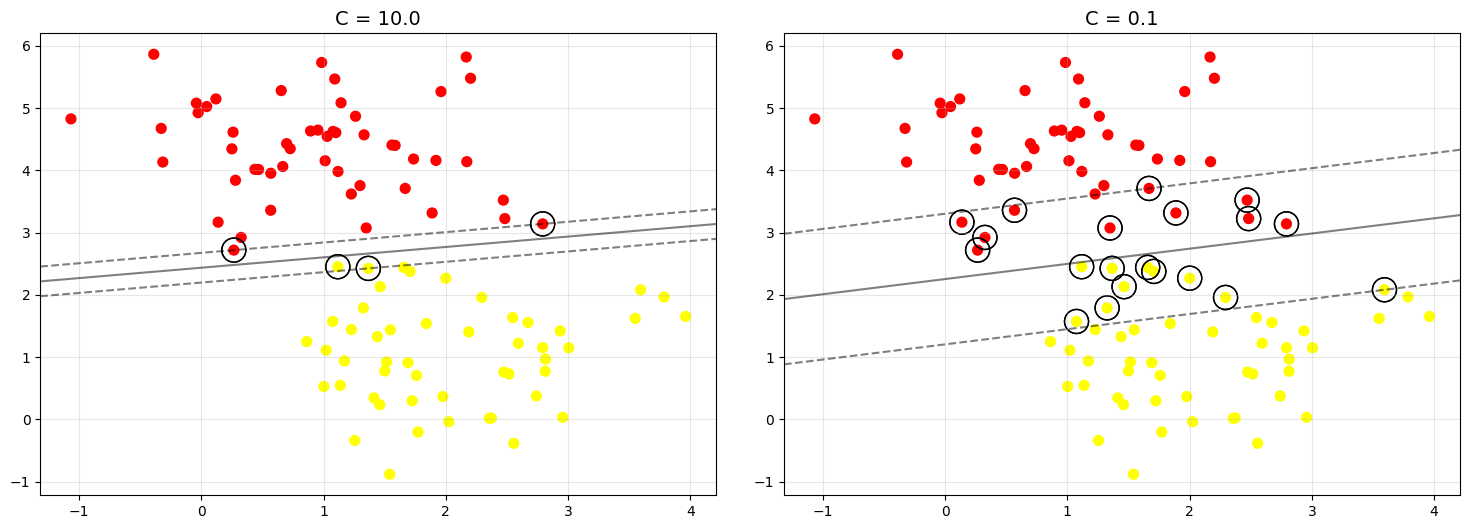

Left (C=10.0): Strict — narrow margin, few support vectors, tries to get every point right
Right (C=0.1): Flexible — wide margin, more support vectors, accepts some errors

The flexible model (small C) often generalizes better to new, unseen data.


In [12]:
# Generate data with some overlap
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

# Compare different C values
C_values = [10.0, 0.1]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, C_values):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none', edgecolors='black')
    axi.set_title(f'C = {C:.1f}', size=14)
    axi.grid(True, alpha=0.3)

plt.show()

print("Left (C=10.0): Strict — narrow margin, few support vectors, tries to get every point right")
print("Right (C=0.1): Flexible — wide margin, more support vectors, accepts some errors")
print("\nThe flexible model (small C) often generalizes better to new, unseen data.")

### Hyperparameter Tuning: C and Gamma

SVMs have **two main hyperparameters** to tune (when using the RBF kernel):

**1. Gamma ($\gamma$) — controls the "reach" of each training point:**
- **Large $\gamma$**: Each point influences only its immediate neighborhood (tight, complex boundary)
- **Small $\gamma$**: Each point influences a wide area (smooth, simple boundary)
- Think of gamma as a "zoom level" — large gamma zooms in on local details

**2. C — controls margin strictness** (as we just discussed)

**How to find the best values?**
- Don't guess! Use **grid search with cross-validation**
- Try a logarithmic range for both parameters
- Typical ranges: $C \in [10^{-2}, 10^3]$, $\gamma \in [10^{-4}, 1]$
- Scikit-Learn's `GridSearchCV` automates this entire process

### [PRACTICE] Effect of Gamma Parameter (RBF Kernel)

Gamma controls the "reach" of each training point:
- **Large gamma** = tight fit, small influence region (risk of overfitting)
- **Small gamma** = loose fit, large influence region (risk of underfitting)

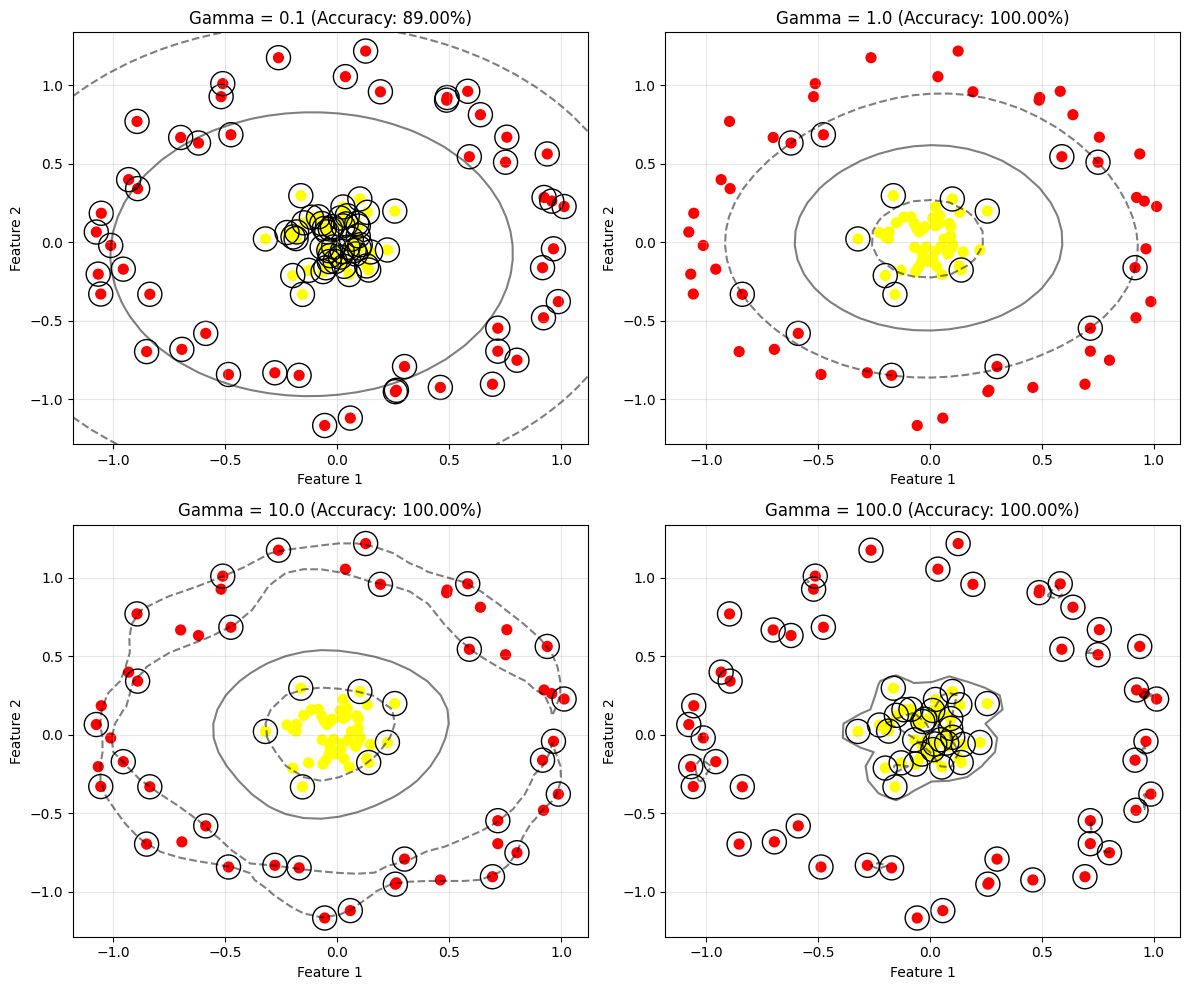

Gamma = 0.1: Too smooth — boundary can't capture the circular pattern
Gamma = 1.0: Just right — captures the circle boundary well
Gamma = 10.0: Getting tight — boundary becomes more complex
Gamma = 100.0: Overfitting! — boundary wraps around individual points


In [13]:
# Generate non-linear data
X_circles, y_circles = make_circles(100, factor=.1, noise=.1)

# Test different gamma values
gamma_values = [0.1, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, gamma in enumerate(gamma_values):
    model = SVC(kernel='rbf', C=1.0, gamma=gamma)
    model.fit(X_circles, y_circles)

    axes[idx].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, s=50, cmap='autumn')
    plot_svc_decision_function(model, axes[idx])
    axes[idx].set_title(f'Gamma = {gamma} (Accuracy: {model.score(X_circles, y_circles):.2%})')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Gamma = 0.1: Too smooth — boundary can't capture the circular pattern")
print("Gamma = 1.0: Just right — captures the circle boundary well")
print("Gamma = 10.0: Getting tight — boundary becomes more complex")
print("Gamma = 100.0: Overfitting! — boundary wraps around individual points")

---
## 5. Example: Face Recognition

Now let's put everything together with a real-world application.

### [TOGETHER] Application: Face Recognition

**Why this example?**

Face recognition is a classic ML problem that demonstrates SVM's strengths:
- **High-dimensional data** — each image has thousands of pixel values
- **Small-to-medium dataset** — we don't need millions of images
- **Clear practical value** — security systems, photo organization, etc.

**Dataset: Labeled Faces in the Wild (LFW)**
- Several thousand photos of public figures
- Multiple photos per person (different lighting, angles, expressions)
- Built-in fetcher in Scikit-Learn
- We'll select people with at least 60 photos for sufficient training data

**Our approach (a 3-step pipeline):**
1. **Dimensionality reduction** with PCA — reduce 2,914 pixel features to 150 meaningful components
2. **Classification** with SVM (RBF kernel)
3. **Hyperparameter tuning** with grid search

### Loading the Face Dataset

In [14]:
from sklearn.datasets import fetch_lfw_people

# Fetch faces with at least 60 photos per person
faces = fetch_lfw_people(min_faces_per_person=60)

print("Categories (people):")
print(faces.target_names)
print(f"\nDataset shape: {faces.images.shape}")
print(f"Number of images: {faces.images.shape[0]}")
print(f"Image size: {faces.images.shape[1]} x {faces.images.shape[2]}")
print(f"Total features per image: {faces.images.shape[1] * faces.images.shape[2]}")

Categories (people):
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']

Dataset shape: (1348, 62, 47)
Number of images: 1348
Image size: 62 x 47
Total features per image: 2914


### Visualize Sample Faces

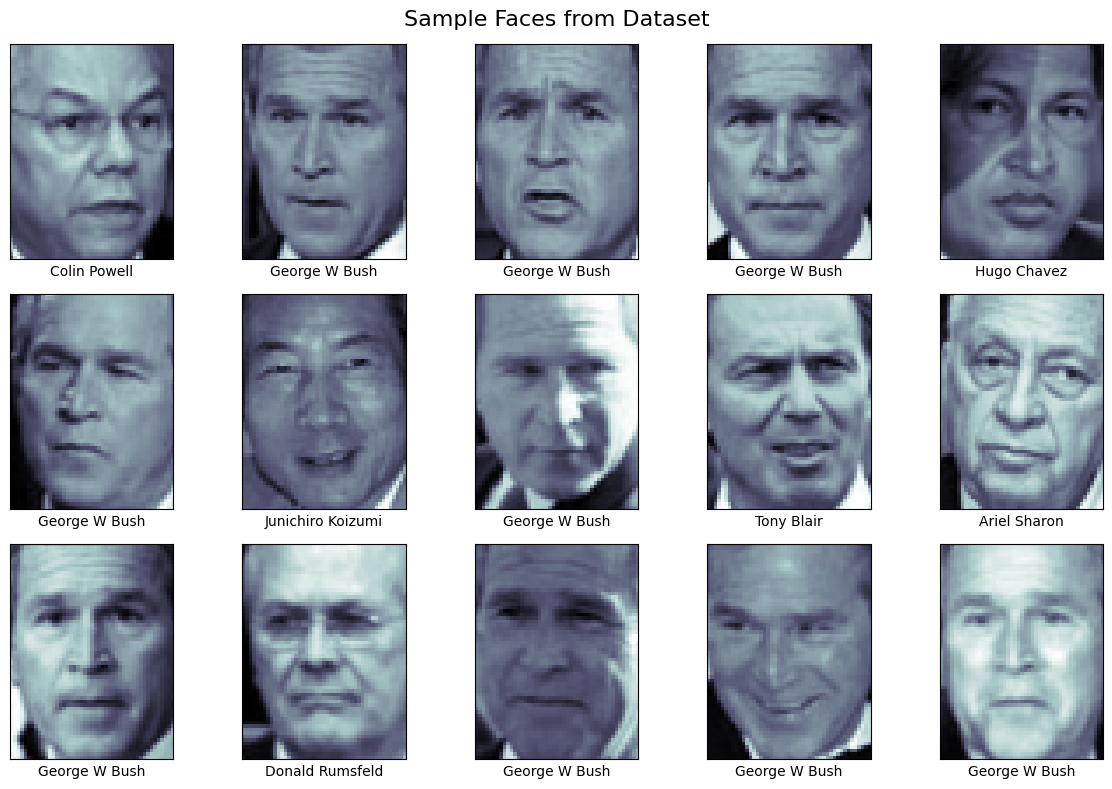

In [15]:
# Plot sample faces
fig, ax = plt.subplots(3, 5, figsize=(12, 8))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])
plt.suptitle('Sample Faces from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

### Challenge: High-Dimensional Data

**The Dimensionality Problem:**
- Each image has $62 \times 47 = 2{,}914$ pixels — that means 2,914 features!
- Using raw pixels directly is problematic:
  - Many pixels are redundant (e.g., background pixels are similar across all images)
  - Too many features relative to the number of samples can cause **overfitting**
  - Training is slow with so many dimensions

**Solution: Principal Component Analysis (PCA)**
- PCA is a dimensionality reduction technique (you'll learn more about it in advanced courses)
- For now, think of it as: PCA finds the **most important patterns** in the images and represents each image using just those patterns
- We reduce 2,914 dimensions down to 150, retaining most of the information

> **Example: Pipeline Approach**  
> We combine PCA (preprocessing) and SVM (classification) into a single Scikit-Learn pipeline — this keeps the code clean and prevents data leakage

### Building the Face Recognition Pipeline

In [16]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

# Create pipeline: PCA (dimension reduction) -> SVM (classification)
pca = PCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

print("Pipeline created:")
print("  Step 1: PCA — reduce 2,914 features to 150 principal components")
print("  Step 2: SVM — classify using RBF kernel")
print("\nPipeline benefits:")
print("  - Preprocessing and classification in one step")
print("  - Prevents data leakage (PCA fitted only on training data)")

Pipeline created:
  Step 1: PCA — reduce 2,914 features to 150 principal components
  Step 2: SVM — classify using RBF kernel

Pipeline benefits:
  - Preprocessing and classification in one step
  - Prevents data leakage (PCA fitted only on training data)


In [17]:
# Split data into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    faces.data, faces.target, random_state=42
)

print(f"Training set size: {Xtrain.shape[0]} images")
print(f"Test set size: {Xtest.shape[0]} images")
print(f"Features per image: {Xtrain.shape[1]}")

Training set size: 1011 images
Test set size: 337 images
Features per image: 2914


### Grid Search for Hyperparameter Tuning

Instead of guessing C and gamma, we systematically try all combinations and pick the best one using cross-validation.

In [18]:
# Define parameter grid
param_grid = {
    'svc__C': [1, 5, 10, 50],
    'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]
}

# Perform grid search with cross-validation
grid = GridSearchCV(model, param_grid, cv=5)

print("Starting grid search...")
print(f"Testing {len(param_grid['svc__C']) * len(param_grid['svc__gamma'])} parameter combinations")
print("Each combination is tested with 5-fold cross-validation")
print("That's 16 x 5 = 80 model fits total. This may take a minute...\n")

%time grid.fit(Xtrain, ytrain)

print(f"\nBest parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.2%}")

Starting grid search...
Testing 16 parameter combinations
Each combination is tested with 5-fold cross-validation
That's 16 x 5 = 80 model fits total. This may take a minute...



CPU times: user 25min 27s, sys: 9min 44s, total: 35min 12s
Wall time: 3min 13s

Best parameters found: {'svc__C': 5, 'svc__gamma': 0.001}
Best cross-validation score: 82.89%


### Evaluating Face Recognition Results

In [19]:
# Use the best model for predictions
best_model = grid.best_estimator_
yfit = best_model.predict(Xtest)

print(f"Test set accuracy: {best_model.score(Xtest, ytest):.2%}")

Test set accuracy: 84.87%


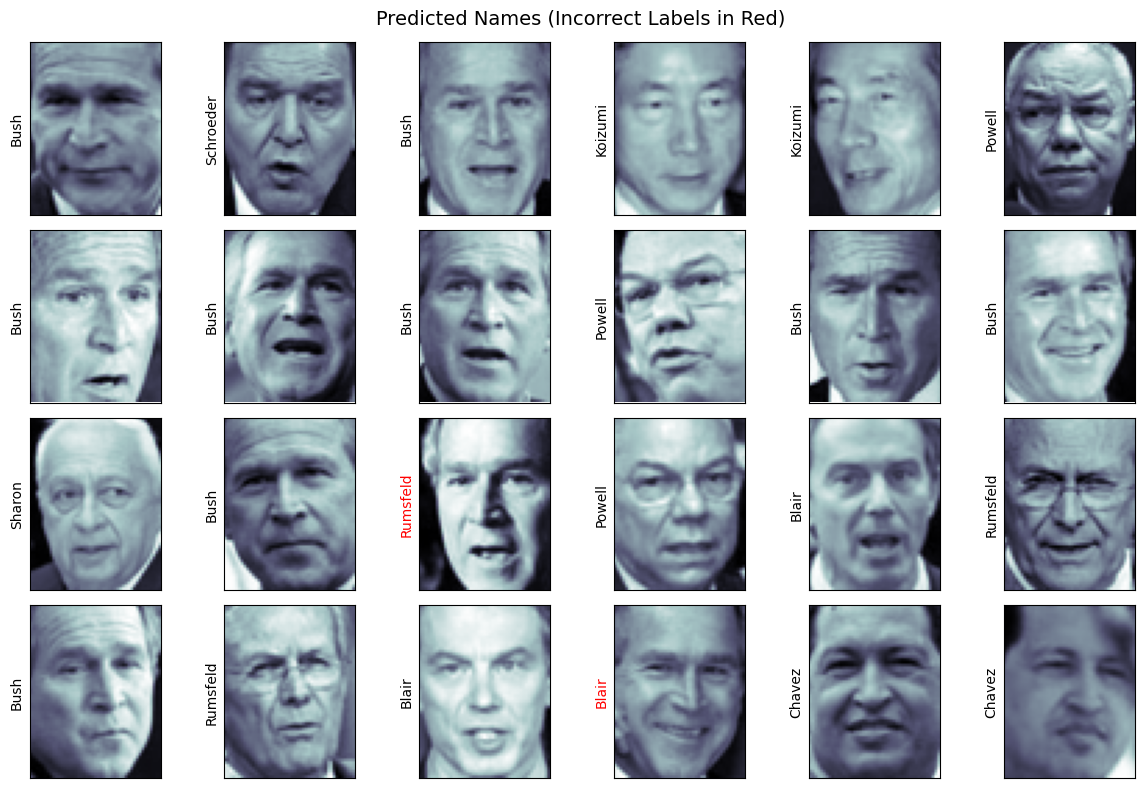

In [20]:
# Show sample predictions
fig, ax = plt.subplots(4, 6, figsize=(12, 8))
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    # Color correct predictions in black, wrong predictions in red
    color = 'black' if yfit[i] == ytest[i] else 'red'
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color=color)
plt.suptitle('Predicted Names (Incorrect Labels in Red)', size=14)
plt.tight_layout()
plt.show()

In [21]:
# Print classification report
print("Classification Report:")
print("=" * 70)
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



**How to read this report:**
- **Precision:** Of all faces the model predicted as "Person X", what fraction were actually Person X? (How trustworthy are positive predictions?)
- **Recall:** Of all actual photos of Person X, what fraction did the model correctly identify? (How many did we miss?)
- **F1-Score:** The harmonic mean of precision and recall — a single number that balances both

> **Example: Civil Engineering Analogy**  
> Precision is like asking "when the sensor says there's a crack, is there really a crack?" Recall is like asking "of all actual cracks, how many did the sensor detect?" 

### Confusion Matrix for Face Recognition

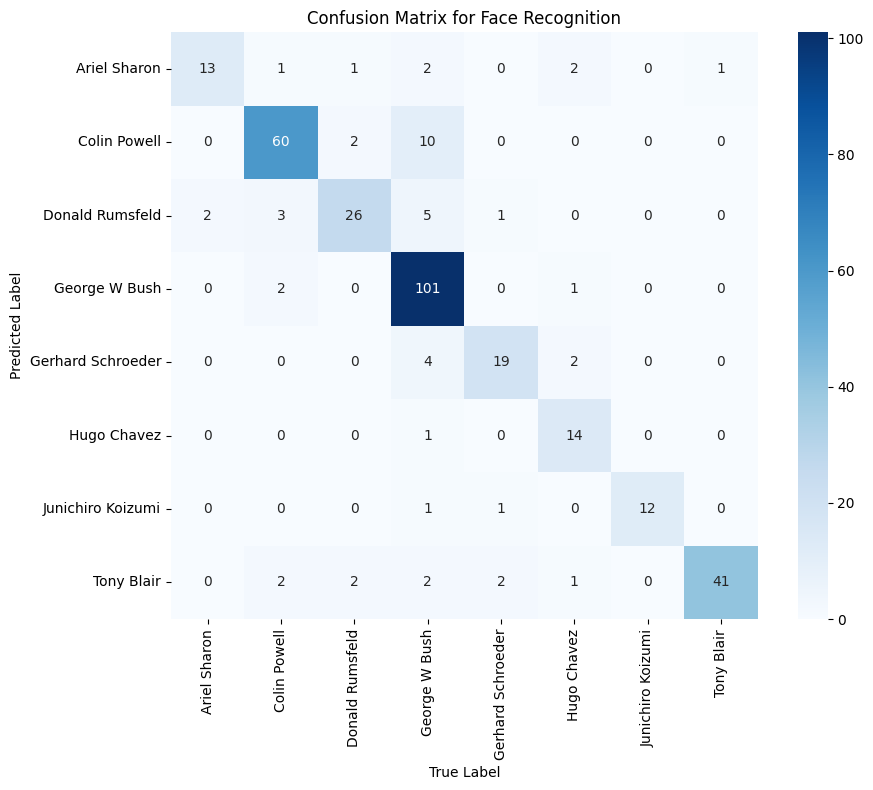

How to read the confusion matrix:
- Diagonal values = correct predictions (the higher, the better)
- Off-diagonal values = mistakes (row = true person, column = predicted person)
- Darker blue = more predictions in that cell


In [22]:
import seaborn as sns

# Compute confusion matrix
mat = confusion_matrix(ytest, yfit)

# Plot confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=True,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names,
            cmap='Blues')
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.title('Confusion Matrix for Face Recognition')
plt.tight_layout()
plt.show()

print("How to read the confusion matrix:")
print("- Diagonal values = correct predictions (the higher, the better)")
print("- Off-diagonal values = mistakes (row = true person, column = predicted person)")
print("- Darker blue = more predictions in that cell")

### Limitations and Modern Approaches

**Limitations of this example:**
- The dataset uses pre-cropped, centered faces — real-world systems need face *detection* first
- Photos are taken in relatively controlled conditions
- Limited training data (60–530 images per person)

**What's used today?**
- Deep learning (Convolutional Neural Networks) has largely replaced PCA+SVM for face recognition
- Modern systems achieve 99%+ accuracy
- But SVM remains relevant for **smaller datasets** where deep learning would overfit

---
## 6. Support Vector Machine Summary

### SVM Advantages

**Why use Support Vector Machines?**

| Advantage | Explanation |
|-----------|-------------|
| **Effective in high dimensions** | Works well even when features outnumber samples (e.g., our face recognition: 2,914 features, ~1,000 training samples) |
| **Memory efficient** | Only support vectors are stored — a small fraction of training data |
| **Versatile** | Different kernels handle different data shapes (linear, circular, complex) |
| **Robust** | Insensitive to points far from the boundary; less affected by outliers |
| **Mathematically sound** | Convex optimization guarantees a unique, globally optimal solution |

### SVM Disadvantages

**When NOT to use SVM:**

| Disadvantage | Details |
|--------------|---------|
| **Slow on large datasets** | Training time scales as $\mathcal{O}(N^2)$ to $\mathcal{O}(N^3)$ — avoid for $N > 10{,}000$ |
| **Hyperparameter sensitive** | Performance depends heavily on choosing the right $C$ and $\gamma$ — requires careful tuning |
| **No direct probabilities** | SVM outputs class labels, not probabilities. Extra steps needed for probability estimates |
| **Less interpretable** | With non-linear kernels, it's hard to explain *why* a particular prediction was made |

### When to Choose SVM vs. Other Models

**Use SVM when:**
- Medium-sized dataset (hundreds to thousands of samples)
- High-dimensional data (many features relative to samples)
- Accuracy matters more than speed or interpretability
- You're willing to invest time in hyperparameter tuning

**Use something else when:**
- Very large dataset ($N > 100{,}000$) → use deep learning or linear models
- Need probability estimates → use logistic regression or Naive Bayes
- Need interpretability → use decision trees or linear models
- Very small dataset → try simpler models first (Naive Bayes, logistic regression)

> **Key Insight: Practical Recommendation**  
> Start with simpler models (logistic regression, Naive Bayes). If they don't perform well enough, *then* try SVM. It's more powerful but requires more tuning effort.

### Key Takeaways

**What you learned today:**

1. **Maximum Margin:** SVM finds the decision boundary with the largest gap between classes
2. **Support Vectors:** Only the points on the margin boundary matter — the rest are irrelevant
3. **Kernel Trick:** Transform data to higher dimensions to handle non-linear boundaries, without actually computing in that space
4. **Soft Margins (C parameter):** Control the trade-off between margin width and misclassifications
5. **Gamma parameter:** Controls how "local" vs. "global" the influence of each point is (for RBF kernel)
6. **Grid Search:** Systematically find the best hyperparameters using cross-validation

**The SVM workflow:**
1. Scale your features (`StandardScaler`)
2. Start with a linear kernel
3. If linear isn't good enough, try RBF
4. Use `GridSearchCV` to tune $C$ and $\gamma$
5. Evaluate on held-out test data

---

## [PRACTICE] Practice Exercises

Try these on your own:

1. **Exercise 1 (Warm-up):** Create your own 2D dataset with `make_blobs` and experiment with different C values (try 0.01, 0.1, 1, 10, 1000). What happens to the margin as C changes? At what point does the model start overfitting?

2. **Exercise 2 (Non-linear data):** Generate a more complex non-linear dataset using `make_moons` from sklearn. Compare linear and RBF kernels. Which one works better, and why?

3. **Exercise 3 (Full pipeline):** Load the digits dataset (`from sklearn.datasets import load_digits`) and build an SVM classifier. Use grid search to find optimal hyperparameters. Can you achieve > 98% accuracy?

4. **Exercise 4 (Multi-class):** Create a dataset with 4 classes using `make_blobs(centers=4)`. Train an SVM on it. How does SVM handle more than 2 classes? *(Hint: look up "one-vs-one" and "one-vs-rest" strategies)*

5. **Exercise 5 (Model comparison):** Compare SVM with Naive Bayes on the same dataset. When does each model win?

In [23]:
# Your code here


---
### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr